In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from tensorflow.keras.datasets import fashion_mnist

In [2]:
(x_train,y_train) , (x_test, y_test)= fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
#x_train[0] #pixels related to one image

In [4]:
x_train.shape # here 60000 is number of images, each image is of 28 x 28

(60000, 28, 28)

In [5]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [6]:
y_train.shape

(60000,)

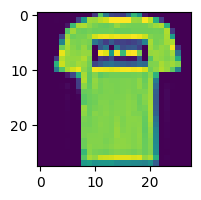

In [7]:
plt.figure(figsize=(15,2))
plt.imshow(x_train[1]) #just to see how image looks like

In [8]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress',
               'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Text(0.5, 0, 'T-shirt/top')

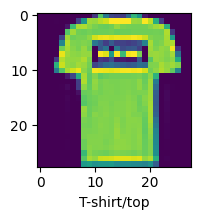

In [9]:
plt.figure(figsize=(15,2))
plt.imshow(x_train[1])
plt.xlabel(class_names[y_train[1]])

In [10]:

x_train= x_train.reshape(-1,28,28,1)
x_test= x_test.reshape(-1,28,28,1)

In [11]:

x_train=x_train /255.0
x_test=x_test /255.0

In [12]:
# x_train[1]

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import TensorBoard

cnn_model = Sequential()
cnn_model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(28,28,1), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(28,28,1), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv2D(filters=64, kernel_size=(3, 3), input_shape=(28,28,1), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(Conv2D(filters=64, kernel_size=(3, 3), input_shape=(28,28,1), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Dropout(0.2))

cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Dropout(0.25))
cnn_model.add(Flatten())
cnn_model.add(Dense(units=128, activation='relu'))
cnn_model.add(Dropout(0.2))
cnn_model.add(Dense(units=10, activation='softmax'))

METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]

cnn_model.compile(loss ='sparse_categorical_crossentropy', optimizer='adam' ,metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,906 (550.41 KB)

 Trainable params: 140,522 (548.91 KB)

 Non-trainable params: 384 (1.50 KB)

In [15]:

epochs = 100
batch_size = 512

history = cnn_model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(x_test, y_test)
)

Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 26s 109ms/step - accuracy: 0.6908 - loss: 0.9739 - val_accuracy: 0.1000 - val_loss: 2.4519
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.8141 - loss: 0.5071 - val_accuracy: 0.2916 - val_loss: 2.3385
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8469 - loss: 0.4197 - val_accuracy: 0.4977 - val_loss: 1.8037
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.8620 - loss: 0.3754 - val_accuracy: 0.6637 - val_loss: 1.1607
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8738 - loss: 0.3441 - val_accuracy: 0.8569 - val_loss: 0.3915
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8843 - loss: 0.3191 - val_accuracy: 0.8867 - val_loss: 0.2961
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8895 - loss: 0.3026 - val_accuracy: 0.9080 - val_loss: 0.2550
Epoch 8/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8955 - loss: 0.2851 

In [16]:
# epoch is the number of times an algorithm passes through a training dataset
# batch size is the number of training examples used in one iteration of model training

In [17]:
loss,accuracy=cnn_model.evaluate(x_test,y_test)
print("Accuracy :" ,accuracy*100,"%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9369 - loss: 0.2721
Accuracy : 93.69000196456909 %


In [18]:
# some predictions

In [19]:
y_predict=cnn_model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [20]:
y_predict[0]

array([2.05692313e-21, 1.54721183e-23, 2.77172794e-21, 1.09959025e-20,
       5.99172518e-21, 3.33202229e-14, 2.13682174e-22, 1.90763139e-08,
       1.96783309e-23, 1.00000000e+00], dtype=float32)

In [21]:

y_pred=y_predict.argmax(axis=-1)

In [22]:
y_pred[0]

np.int64(9)

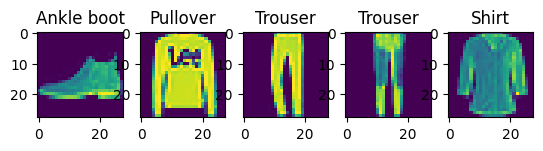

In [23]:
for i in range(5):
    plt.subplot(1,5,i+1) # 1 row and 5 columns
    plt.imshow(x_test[i])
    plt.title(class_names[y_pred[i]])

In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1000
           1       0.99      0.99      0.99      1000
           2       0.93      0.89      0.91      1000
           3       0.93      0.95      0.94      1000
           4       0.86      0.95      0.90      1000
           5       0.99      0.99      0.99      1000
           6       0.84      0.78      0.81      1000
           7       0.95      0.99      0.97      1000
           8       0.99      0.98      0.99      1000
           9       0.99      0.95      0.97      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000

